In [1]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
import regina
import numpy as np

In [2]:
def check_closed(iso_sig):
    try:
        T = regina.engine.Triangulation3.rehydrate(iso_sig)
        closed = T.isClosed()
    except:
        closed = False

    return closed

In [3]:
res_path = data_root / "results" / "sgd_models_dehydration" / "scale"

In [4]:
models = [
    "spheres_1024emb_24block_8head_10tet",
    "spheres_512emb_6block_4head_10tet",
    "spheres_768emb_12block_6head_10tet",
    "spheres_1536emb_32block_12head_10tet",
    "spheres_256emb_4block_4head_10tet"
]

flops_map = {
    "spheres_1024emb_24block_8head_10tet": 302_452_736,
    "spheres_768emb_12block_6head_10tet": 85_161_984,
    "spheres_512emb_6block_4head_10tet": 18_985_984,
    "spheres_256emb_4block_4head_10tet": 3_194_880,
}

In [5]:
for model in models:
    try:
        p = res_path / model
    except:
        pass

In [6]:
p_closed = {}

for model in models:
    p = res_path / model
    data = {}
    for f in p.iterdir():
        if f.name.startswith('gen') and f.name != 'generated_samples.txt':
            n_itts = f.name.split('_')[-1]
            n_itts = n_itts.split('.')[0]
            n_itts = n_itts.replace(',', '')
            n_itts = int(n_itts)

            if n_itts % 10 == 9:
                n_itts = n_itts + 1

            n_flops = n_itts * flops_map[model]


            with open(f, "r") as f:
                lines = f.readlines()

            closed = []

            samps_str = [line.strip() for line in lines]
            for i, iso in enumerate(samps_str):
                closed.append(check_closed(iso))
            data[n_flops] = np.mean(closed)

    p_closed[model] = pd.Series(data).sort_index()

In [7]:
train_losses = {}
test_losses = {}

for model in models:
    try:
        p = res_path / model / "train_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        train_losses[model] = data

        p = res_path / model / "test_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        test_losses[model] = data
    except:
        pass

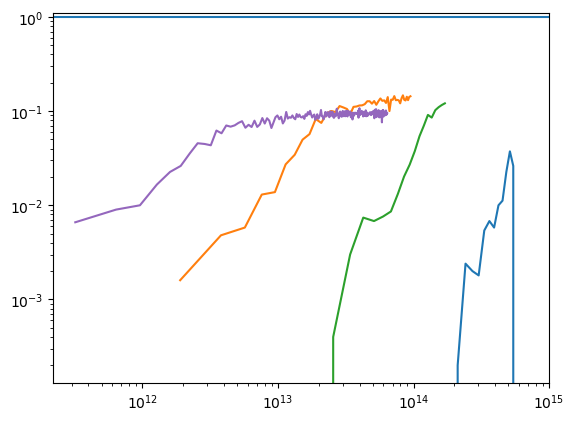

In [8]:
for model in models:
    try:
        plt.plot(p_closed[model])
    except:
        pass

plt.axhline(1)

# plt.axvline(10**(13.5))
# plt.axvline(10**(14.27))
# plt.axvline(10**(14.93))

plt.loglog()
plt.xlim([None, 1e15])
plt.ylim([None, 1.1])
plt.show()

In [9]:
test_losses

{'spheres_1024emb_24block_8head_10tet': 3024527360000      1.866615
 6049054720000      1.891925
 9073582080000      1.855258
 12098109440000     1.837562
 15122636800000     1.869911
                      ...   
 592807362560000    1.157075
 595831889920000    1.244028
 598856417280000    1.161798
 601880944640000    1.380981
 604905472000000    1.273871
 Name: 1, Length: 200, dtype: float64,
 'spheres_512emb_6block_4head_10tet': 189859840000      1.363064
 379719680000      1.292647
 569579520000      1.269171
 759439360000      1.261595
 949299200000      1.234598
                     ...   
 94170480640000    0.876645
 94360340480000    0.876298
 94550200320000    0.876868
 94740060160000    0.877915
 94929920000000    0.877224
 Name: 1, Length: 500, dtype: float64,
 'spheres_768emb_12block_6head_10tet': 851619840000       1.608580
 1703239680000      1.599120
 2554859520000      1.593699
 3406479360000      1.567471
 4258099200000      1.574516
                      ...   
 166917

/tmp/ipykernel_15782/4204082434.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e15])


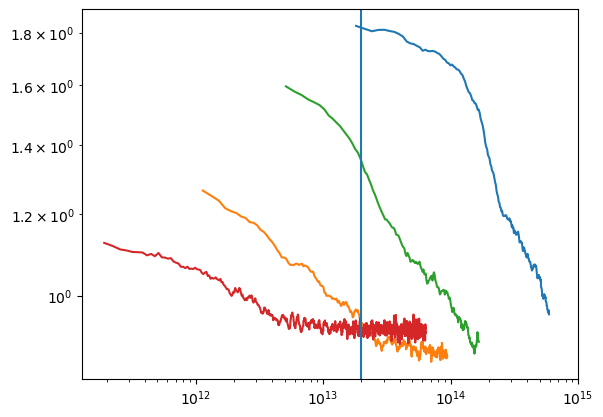

In [10]:
for model in models:
    try:
        plt.plot(train_losses[model].rolling(10, center=True).mean())
    except:
        pass

plt.loglog()
plt.axvline(10**(13.3))

plt.xlim([0, 1e15])
plt.show()

In [11]:
np.sqrt(18000000*1000000*480)

np.float64(92951600.308978)

In [12]:
np.sqrt(18000000*1000000*480/20)

np.float64(20784609.690826528)

In [13]:
20_000_000 * 20 / 480

833333.3333333334

In [14]:
# 20_000_000 at d = 850_000

In [15]:
# p = 3,145,728 at d = 6_342_768
# p = 18,874,368 at d = 1_057_128